# Participant-Level XSENS vs Vicon Agreement

This notebook compares XSENS-derived features against Vicon annotations at the participant level.

- Keeps only SRS stroke participants.
- Matches by `subject_id` and visit.
- Uses the first available matched visit per subject, so each subject contributes one row.
- Shows patient-by-patient errors, scatter plots, and Bland-Altman plots.

In [1]:
from pathlib import Path
import sys
import pandas as pd

cwd = Path.cwd()
if (cwd / "agreement_plots.py").exists():
    sys.path.insert(0, str(cwd))
elif (cwd / "Sensors_Visualizers" / "agreement_plots.py").exists():
    sys.path.insert(0, str(cwd / "Sensors_Visualizers"))

from agreement_plots import SPECS, all_metric_summary, display_feature_report, participant_agreement_table

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

spec_by_title = {spec.title: spec for spec in SPECS}
print("Setup complete")

Setup complete


## Metric Summary

Use this table to decide which features are strongest before showing the plots.

In [2]:
summary = all_metric_summary()
display(summary.sort_values(["activity", "feature"]))

,activity,feature,xsens_column,vicon_column,unit,n,mae,rmse,bias,pearson_r,icc_a1
2,left_turn,Left Turn Duration,sacrum_turn_duration,left_turn_duration_s,s,15,0.894,1.166,0.176,0.900,0.884
3,left_turn,Left Turn Step Count,sacrum_turn_step_count,left_turn_step_count,steps,15,1.467,1.789,-0.133,0.874,0.778
4,right_turn,Right Turn Duration,sacrum_turn_duration,right_turn_duration_s,s,16,1.058,1.594,-0.367,0.896,0.896
5,right_turn,Right Turn Step Count,sacrum_turn_step_count,right_turn_step_count,steps,16,2.531,3.223,0.469,0.801,0.723
6,sit_to_stand,Sit-to-Stand Duration,sacrum_duration,sts_duration_s,s,15,0.581,0.754,-0.303,0.496,0.420
1,walking,Walking Cadence,sacrum_qc_cadence,walk_cadence_steps_min,steps/min,16,11.906,14.054,-0.031,0.769,0.760
0,walking,Walking Step Count,sacrum_qc_step_count,walk_step_count,steps,16,11.906,14.054,-0.031,0.769,0.760


## Walking Step Count

,n,mae,rmse,bias,pearson_r,icc_a1
0,16,11.906,14.054,-0.031,0.769,0.76


,subject_id,vicon,xsens,error,abs_error,percent_error
0,SRS02,84.0,84.5,0.5,0.5,0.595
1,SRS10,43.0,42.0,-1.0,1.0,2.326
2,SRS17,34.0,38.5,4.5,4.5,13.235
3,SRS14,42.0,47.5,5.5,5.5,13.095
4,SRS13,54.0,46.5,-7.5,7.5,13.889
5,SRS12,58.0,66.5,8.5,8.5,14.655
6,SRS15,40.0,48.5,8.5,8.5,21.250
7,SRS04,58.0,47.5,-10.5,10.5,18.103
8,SRS09,62.5,73.5,11.0,11.0,17.600
9,SRS18,36.0,48.5,12.5,12.5,34.722


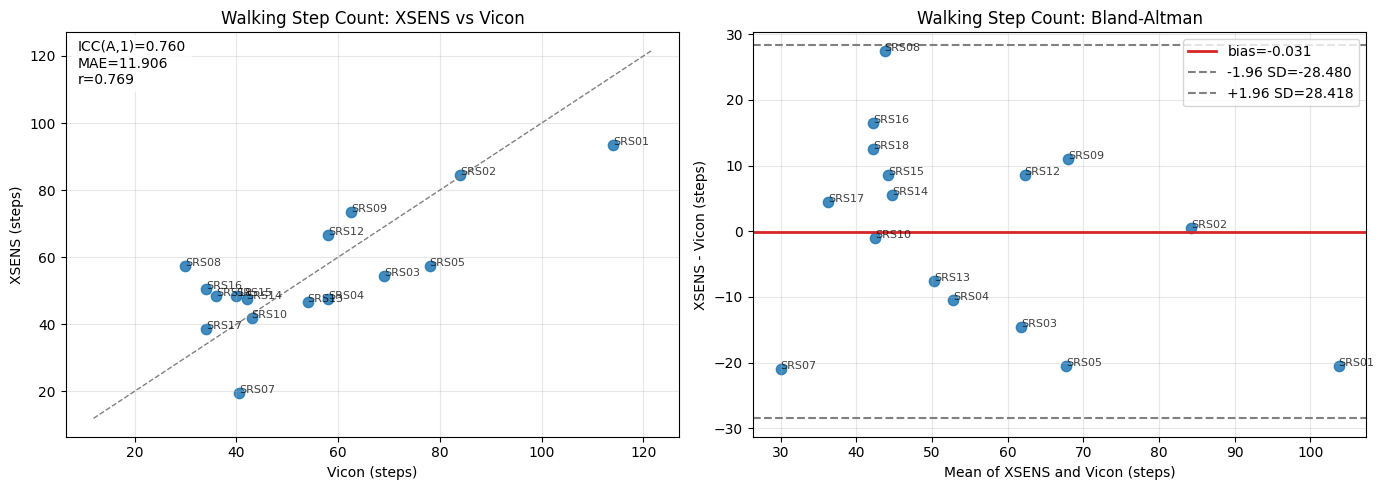

In [3]:
display_feature_report(spec_by_title["Walking Step Count"])

## Walking Cadence

,n,mae,rmse,bias,pearson_r,icc_a1
0,16,11.906,14.054,-0.031,0.769,0.76


,subject_id,vicon,xsens,error,abs_error,percent_error
0,SRS02,84.0,84.5,0.5,0.5,0.595
1,SRS10,43.0,42.0,-1.0,1.0,2.326
2,SRS17,34.0,38.5,4.5,4.5,13.235
3,SRS14,42.0,47.5,5.5,5.5,13.095
4,SRS13,54.0,46.5,-7.5,7.5,13.889
5,SRS12,58.0,66.5,8.5,8.5,14.655
6,SRS15,40.0,48.5,8.5,8.5,21.250
7,SRS04,58.0,47.5,-10.5,10.5,18.103
8,SRS09,62.5,73.5,11.0,11.0,17.600
9,SRS18,36.0,48.5,12.5,12.5,34.722


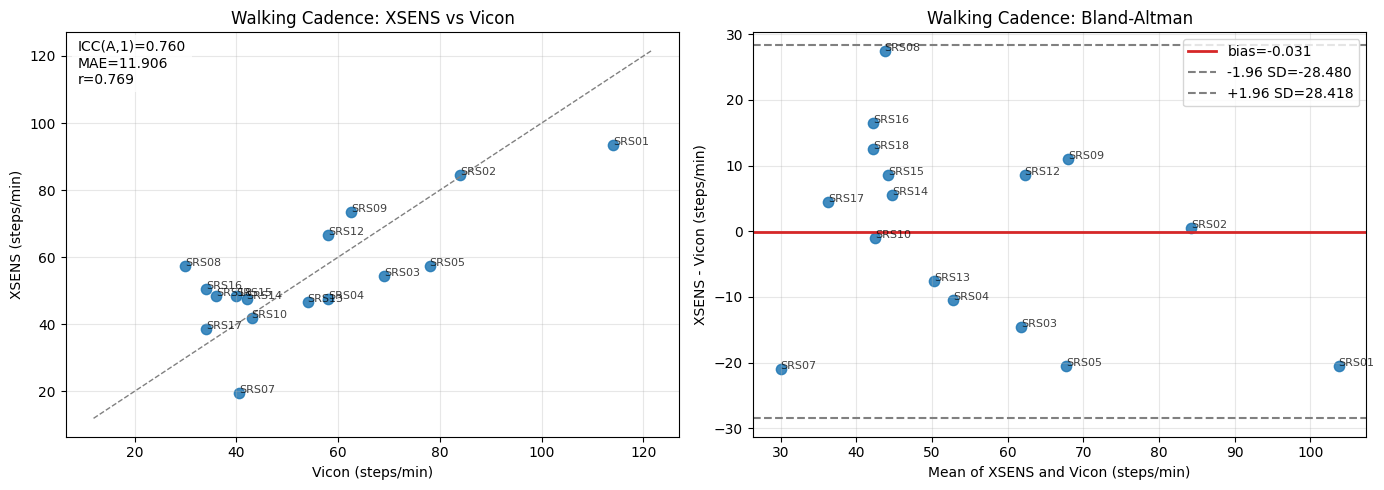

In [4]:
display_feature_report(spec_by_title["Walking Cadence"])

## Left Turn Duration

,n,mae,rmse,bias,pearson_r,icc_a1
0,15,0.894,1.166,0.176,0.9,0.884


,subject_id,vicon,xsens,error,abs_error,percent_error
0,SRS09,4.20,4.240,0.040,0.040,0.952
1,SRS15,9.80,9.730,-0.070,0.070,0.714
2,SRS13,5.20,4.950,-0.250,0.250,4.808
3,SRS08,5.10,4.800,-0.300,0.300,5.882
4,SRS10,4.25,3.850,-0.400,0.400,9.412
5,SRS12,8.00,8.550,0.550,0.550,6.875
6,SRS05,7.50,6.940,-0.560,0.560,7.467
7,SRS16,6.50,7.230,0.730,0.730,11.231
8,SRS07,8.60,7.770,-0.830,0.830,9.651
9,SRS14,9.80,10.730,0.930,0.930,9.490


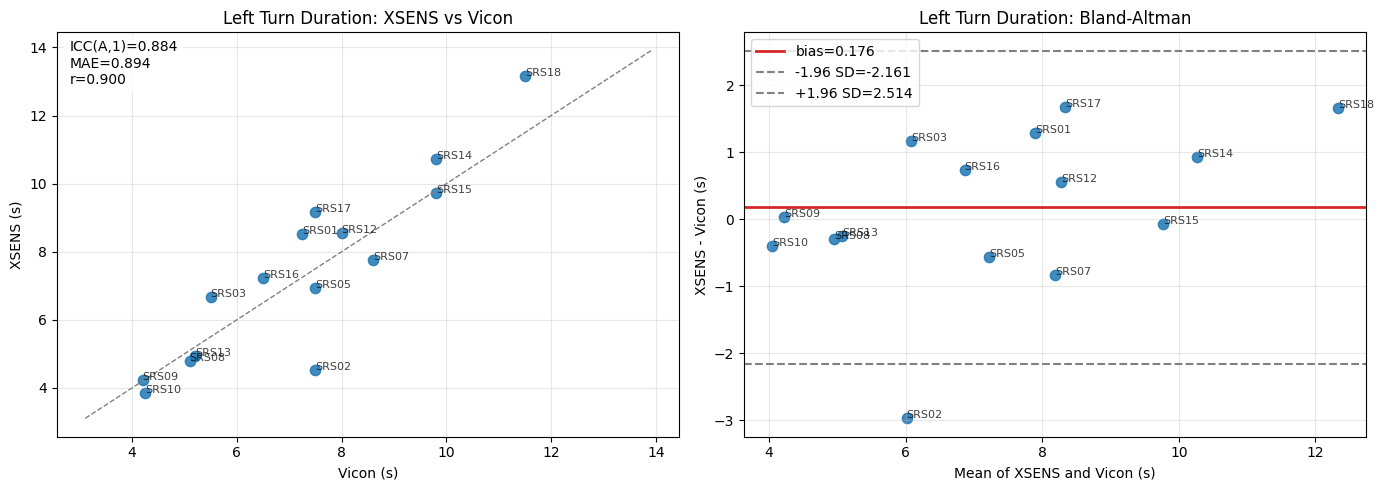

In [5]:
display_feature_report(spec_by_title["Left Turn Duration"])

## Left Turn Step Count

,n,mae,rmse,bias,pearson_r,icc_a1
0,15,1.467,1.789,-0.133,0.874,0.778


,subject_id,vicon,xsens,error,abs_error,percent_error
0,SRS03,11.0,11.0,0.0,0.0,0.000
1,SRS07,10.0,10.0,0.0,0.0,0.000
2,SRS05,9.0,10.0,1.0,1.0,11.111
3,SRS09,7.0,6.0,-1.0,1.0,14.286
4,SRS12,9.0,10.0,1.0,1.0,11.111
5,SRS13,9.0,8.0,-1.0,1.0,11.111
6,SRS14,13.0,14.0,1.0,1.0,7.692
7,SRS16,12.0,11.0,-1.0,1.0,8.333
8,SRS18,14.0,15.0,1.0,1.0,7.143
9,SRS01,10.5,12.5,2.0,2.0,19.048


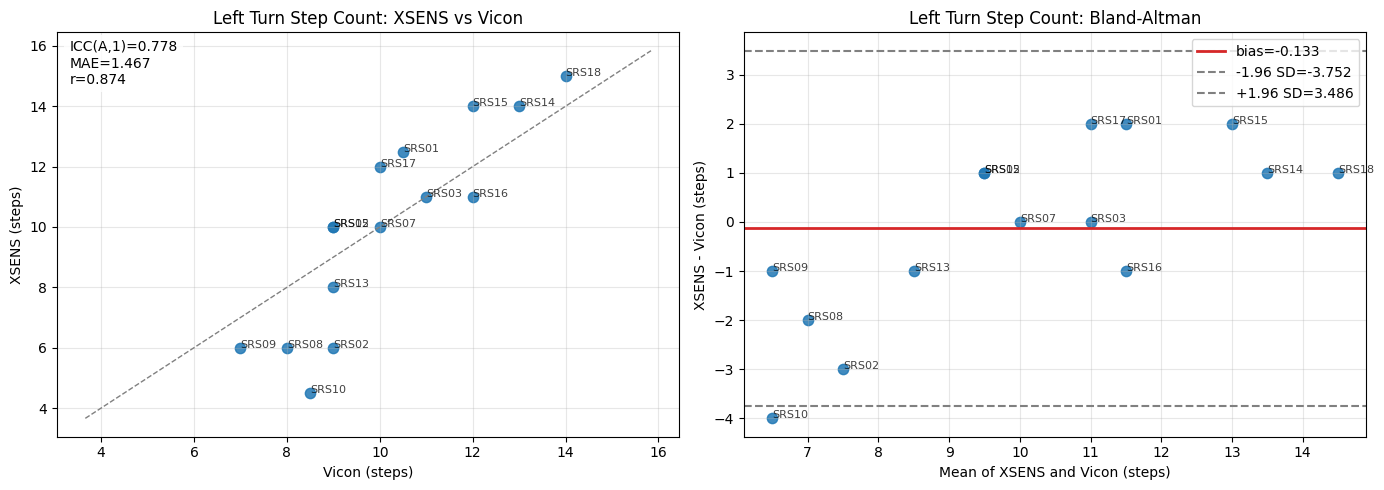

In [6]:
display_feature_report(spec_by_title["Left Turn Step Count"])

## Right Turn Duration

,n,mae,rmse,bias,pearson_r,icc_a1
0,16,1.058,1.594,-0.367,0.896,0.896


,subject_id,vicon,xsens,error,abs_error,percent_error
0,SRS10,4.75,4.815,0.065,0.065,1.368
1,SRS03,8.00,7.800,-0.200,0.200,2.500
2,SRS09,3.70,3.290,-0.410,0.410,11.081
3,SRS17,5.60,6.010,0.410,0.410,7.321
4,SRS13,4.10,3.660,-0.440,0.440,10.732
5,SRS16,11.10,11.540,0.440,0.440,3.964
6,SRS12,9.90,10.400,0.500,0.500,5.051
7,SRS18,14.80,15.310,0.510,0.510,3.446
8,SRS08,5.40,5.960,0.560,0.560,10.370
9,SRS14,13.10,13.710,0.610,0.610,4.656


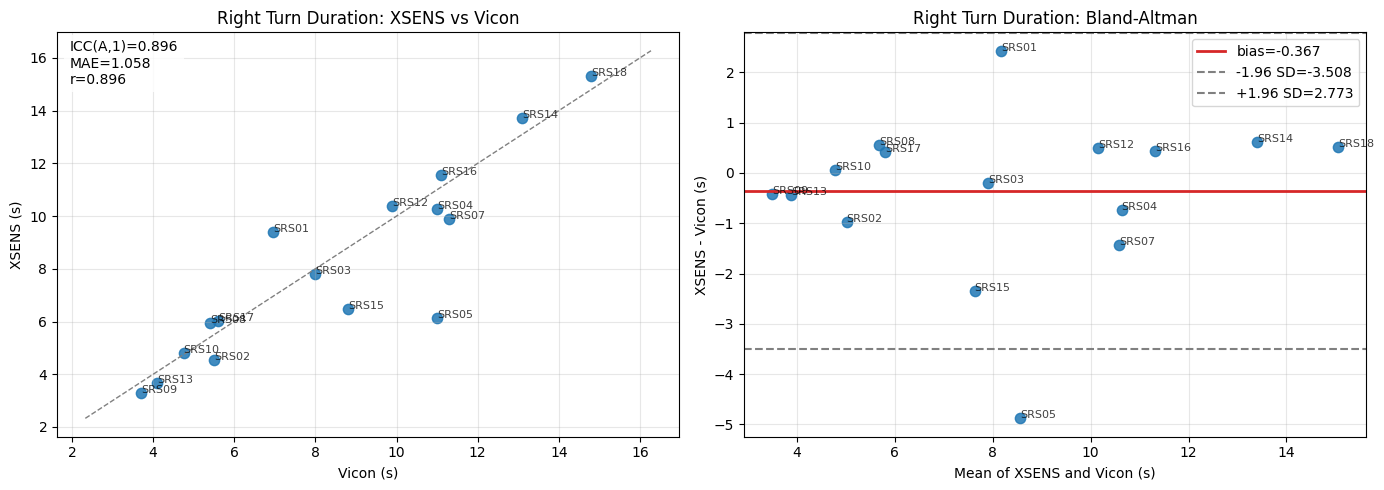

In [7]:
display_feature_report(spec_by_title["Right Turn Duration"])

## Right Turn Step Count

,n,mae,rmse,bias,pearson_r,icc_a1
0,16,2.531,3.223,0.469,0.801,0.723


,subject_id,vicon,xsens,error,abs_error,percent_error
0,SRS13,6.0,6.0,0.0,0.0,0.000
1,SRS16,15.0,15.0,0.0,0.0,0.000
2,SRS02,7.0,6.0,-1.0,1.0,14.286
3,SRS07,11.5,12.5,1.0,1.0,8.696
4,SRS10,8.5,7.5,-1.0,1.0,11.765
5,SRS12,13.0,14.0,1.0,1.0,7.692
6,SRS05,10.0,8.0,-2.0,2.0,20.000
7,SRS08,6.0,8.0,2.0,2.0,33.333
8,SRS15,10.0,8.0,-2.0,2.0,20.000
9,SRS09,6.5,4.0,-2.5,2.5,38.462


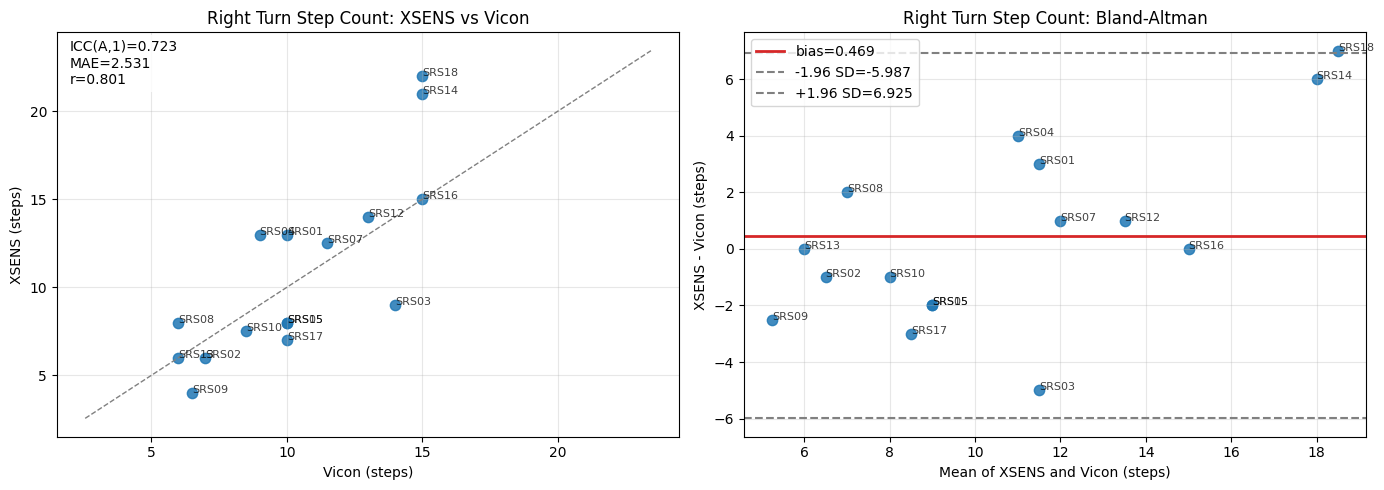

In [8]:
display_feature_report(spec_by_title["Right Turn Step Count"])

## Sit-to-Stand Duration

,n,mae,rmse,bias,pearson_r,icc_a1
0,15,0.581,0.754,-0.303,0.496,0.42


,subject_id,vicon,xsens,error,abs_error,percent_error
0,SRS02,1.00,1.000,0.000,0.000,0.000
1,SRS16,2.70,2.800,0.100,0.100,3.704
2,SRS10,1.90,2.005,0.105,0.105,5.526
3,SRS17,1.70,1.810,0.110,0.110,6.471
4,SRS09,1.20,1.360,0.160,0.160,13.333
5,SRS01,1.45,1.160,-0.290,0.290,20.000
6,SRS08,1.20,0.850,-0.350,0.350,29.167
7,SRS07,2.00,1.575,-0.425,0.425,21.250
8,SRS05,2.30,1.650,-0.650,0.650,28.261
9,SRS13,1.10,1.830,0.730,0.730,66.364


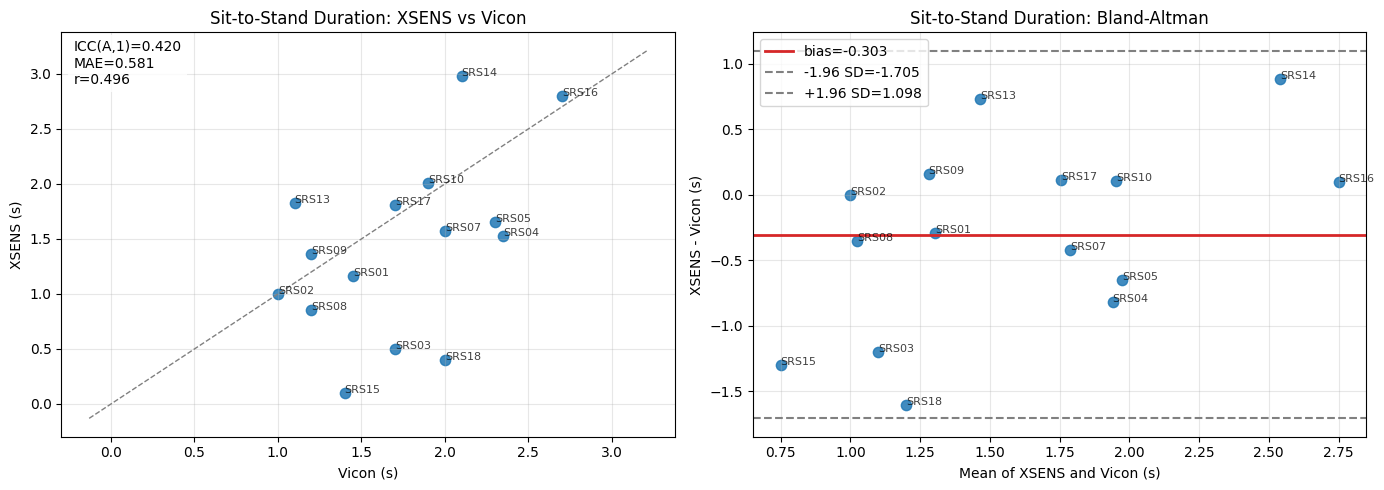

In [9]:
display_feature_report(spec_by_title["Sit-to-Stand Duration"])